# Bankruptcy Risk Modeling

ADS 505 Final Project, modeling section (Macoi Hollins)

GitHub: https://github.com/jblackman-bit/ADS-505-Final-Project

This notebook continues the analysis from `eda.ipynb`. It reads `bankruptcy_clean.csv`, addresses a scaling issue found in 24 columns, splits the data into training, validation, and test sets, and compares three tuned models with a simple Altman-style baseline. It also develops risk tiers, reviews where the selected model misses bankruptcies, and ends with a model brief. These sections will later be merged into the team notebook, so the section numbers are specific to this file.

Figures are saved to `figures/`, and the model comparison table is saved to `results/` for use in the final brief and presentation.

The notebook was tested with Python 3.13, pandas 3.0, scikit-learn 1.9, NumPy 2.5, SciPy 1.18, and matplotlib 3.11. It requires scikit-learn 1.2 or newer for class weights in gradient boosting and Jinja2 for the styled tables. A full run takes about 15 minutes.

In [1]:
# All imports live in this first cell, per the project requirements
import os
import warnings

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy.stats import loguniform, randint
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import (HistGradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_auc_score)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
TARGET = 'Bankrupt?'

# Same two class colors as eda.ipynb so the merged notebook looks consistent
PALETTE = {'Solvent': '#2b5c8f', 'Bankrupt': '#d9534f'}
# One fixed color and line style per model, used in every chart below
MODEL_STYLE = {
    'Altman-style baseline': {'color': '#8a8a8a', 'ls': '--'},
    'Logistic regression': {'color': '#2f6fb3', 'ls': '-'},
    'Random forest': {'color': '#2a9d6f', 'ls': '-.'},
    'Gradient boosting': {'color': '#e07b18', 'ls': ':'},
}

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'font.size': 10})

os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

## 1. Load the cleaned data

The data comes from the Taiwanese Bankruptcy Prediction dataset (Yeh, 2020). `bankruptcy_clean.csv` is the output from `eda.ipynb`, where extra spaces were removed from column names and the constant `Net Income Flag` variable was dropped.

In [2]:
df = pd.read_csv('bankruptcy_clean.csv')
X = df.drop(columns=TARGET)
y = df[TARGET]

print(f'{X.shape[0]:,} companies, {X.shape[1]} predictors')
print(f'Bankrupt: {y.sum()} ({y.mean():.2%})')

6,819 companies, 94 predictors
Bankrupt: 220 (3.23%)


## 2. Pre-processing

### 2.1 A scaling problem in 24 columns

Almost every predictor in this dataset is scaled between 0 and 1, but 24 columns also contain values in the millions or billions. These values were treated as outliers during the EDA. After reviewing them more closely, they appear to follow a different scale rather than behaving like typical outliers. There are no values between the two groups: a cell is either within the normal 0-to-1 range or contains a value such as 9,990,000,000. Some of these values also cannot represent the ratio listed in the column. For example, `Fixed Assets to Assets` should not exceed 1, but one company has a value of 8.3 billion.

We believe these cells were stored in raw, unscaled units while the rest of the column was normalized. The table below shows how many cells are affected in each column and compares the bankruptcy rate for companies with a raw-scale value with the rate for the remaining companies.

In [3]:
raw_mask = X > 1
raw_cols = raw_mask.sum()[lambda s: s > 0].sort_values(ascending=False)

raw_summary = pd.DataFrame({
    'Raw-scale cells': raw_cols,
    'Share of rows': raw_cols / len(X),
    'Smallest raw value': [X.loc[raw_mask[c], c].min()
                           for c in raw_cols.index],
    'Largest normal value': [X.loc[~raw_mask[c], c].max()
                             for c in raw_cols.index],
    'Bankrupt rate (raw)': [y[raw_mask[c]].mean() for c in raw_cols.index],
    'Bankrupt rate (normal)': [y[~raw_mask[c]].mean() for c in raw_cols.index],
})

raw_summary.style.format({
    'Share of rows': '{:.1%}', 'Smallest raw value': '{:,.0f}',
    'Largest normal value': '{:.3f}', 'Bankrupt rate (raw)': '{:.1%}',
    'Bankrupt rate (normal)': '{:.1%}'})

,Raw-scale cells,Share of rows,Smallest raw value,Largest normal value,Bankrupt rate (raw),Bankrupt rate (normal)
Total Asset Growth Rate,6017,88.2%,"583,000",1.000,3.5%,1.0%
Cash Turnover Rate,4239,62.2%,"661,000",1.000,4.3%,1.4%
Research and development expense rate,4033,59.1%,"17,000,000",1.000,3.0%,3.6%
Inventory Turnover Rate (times),2946,43.2%,"19,100,000",1.000,4.0%,2.6%
Quick Asset Turnover Rate,2383,34.9%,"8,820,000",1.000,4.1%,2.8%
Operating Expense Rate,2282,33.5%,"604,000",1.000,2.9%,3.4%
Current Asset Turnover Rate,1234,18.1%,"3,780,000",1.000,4.3%,3.0%
Fixed Assets Turnover Frequency,1228,18.0%,"15,100,000",1.000,6.8%,2.4%
Interest-bearing debt interest rate,221,3.2%,"1,000,000",1.000,0.9%,3.3%
Long-term Liability to Current Assets,109,1.6%,"12,500,000",1.000,1.8%,3.2%


Two patterns stand out. First, the separation between the two scales is clear in every affected column: the largest normal value is no greater than 1, while the smallest raw-scale value is in the hundreds of thousands. Second, the presence of a raw-scale value sometimes carries useful information. For example, companies with a raw `Cash/Current Liability` value go bankrupt at about ten times the rate of the remaining companies. Because of that, the raw-scale indicator should not be discarded completely.

The correction is handled inside each model pipeline so that it is learned from the training data only. Values above 1 are treated as missing and replaced with the training median for that column. For columns with at least 10 raw-scale observations in the training data, a separate 0/1 indicator is also added so the model can retain information about whether the original value was on the raw scale.

Because this preprocessing decision changes how those values are interpreted, it should be reviewed by the team. The original `bankruptcy_clean.csv` file is not changed.

In [4]:
class RawScaleFixer(BaseEstimator, TransformerMixin):
    """Blank out values above 1 and flag columns where that happens often.

    Values above 1 are treated as raw-unit entries in otherwise 0-1 ratio
    columns. Which columns get a flag is decided from the training data
    only, so nothing leaks from validation or test rows.
    """

    def __init__(self, min_count=10):
        self.min_count = min_count

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        counts = (X > 1).sum()
        self.flag_cols_ = counts[counts >= self.min_count].index.tolist()
        self.feature_names_in_ = np.array(X.columns)
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_in_).copy()
        flags = (X[self.flag_cols_] > 1).astype(int)
        flags.columns = [f'{c} [raw flag]' for c in self.flag_cols_]
        X = X.mask(X > 1)
        return pd.concat([X, flags], axis=1)

    def get_feature_names_out(self, input_features=None):
        flags = [f'{c} [raw flag]' for c in self.flag_cols_]
        return np.array(list(self.feature_names_in_) + flags)


class ColumnDropper(BaseEstimator, TransformerMixin):
    """Drop a fixed list of columns (used for redundant features)."""

    def __init__(self, columns=()):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return pd.DataFrame(X).drop(columns=list(self.columns),
                                    errors='ignore')

### 2.2 Missing values, outliers, and correlated features

There are no missing values in the original file, as confirmed during the EDA. The only missing values used in the modeling pipeline are the ones intentionally created in Section 2.1, and those values are filled with the training median.

After the raw-scale values are handled, the remaining extreme values are kept. In this dataset, companies at the extremes may represent financially distressed firms, so removing those observations could also remove useful predictive information.

For the logistic regression model, we use the correlated-feature pruning list created during the EDA. Near-duplicate variables can make logistic regression coefficients unstable. The tree-based models are less affected by this issue, so they retain the full feature set. We also remove `Current Liability to Equity` because it is identical to `Current Liabilities/Equity`.

In [5]:
# Redundant columns from the EDA pruning table, plus one exact duplicate
LINEAR_DROP = [
    'ROA(B) before interest and depreciation after tax',
    'ROA(C) before interest and depreciation before interest',
    'Net Value Per Share (B)',
    'Net Value Per Share (C)',
    'Net worth/Assets',
    'Realized Sales Gross Margin',
    'Current Liabilities/Liability',
    'Current Liability to Equity',
]
missing = [c for c in LINEAR_DROP if c not in X.columns]
print('All drop columns found' if not missing else f'Not found: {missing}')

All drop columns found


## 3. Data splitting

We use a 60 / 20 / 20 stratified split so that the bankruptcy rate of approximately 3.2% is maintained across the training, validation, and test sets.

The training set is used to fit the models and tune hyperparameters with 5-fold stratified cross-validation. The validation set is used to compare the tuned models and define the decision thresholds and risk tiers. The test set is reserved until the end and is used only to evaluate the selected model.

There are only 220 bankruptcies in the full dataset, which leaves about 44 bankruptcies in both the validation and test sets. Because the number of positive cases is small, results from any single split may vary. Section 7 evaluates how stable the results are across additional random splits.

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED)

split_summary = pd.DataFrame({
    'Companies': [len(X_train), len(X_val), len(X_test)],
    'Bankrupt': [y_train.sum(), y_val.sum(), y_test.sum()],
    'Bankrupt rate': [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=['Train', 'Validation', 'Test'])
split_summary.style.format({'Companies': '{:,}', 'Bankrupt rate': '{:.2%}'})

,Companies,Bankrupt,Bankrupt rate
Train,"4,091",132,3.23%
Validation,"1,364",44,3.23%
Test,"1,364",44,3.23%


## 4. Model building strategy

### Research questions

1. Can a model using the full feature set identify bankrupt companies better than a simpler score based on five ratios related to Altman's (1968) Z-score?
2. If a nonprofit outreach team can contact only a limited share of companies, how many eventual bankruptcies can the model capture within that outreach capacity?
3. Which financial signals contribute most to the risk ranking, and do those signals make financial sense?

### How we judge the models

Accuracy is not a useful primary metric for this problem because predicting every company as solvent would still produce about 96.8% accuracy. Our main metric is PR-AUC (average precision), which evaluates how well the model ranks bankrupt companies above solvent companies and is more informative when the positive class is rare. A random ranking would score close to the bankruptcy base rate of about 0.03.

We also report capture rates: if the outreach team can contact only the highest-risk 5%, 10%, or 15% of companies, what share of all bankruptcies appears in that group? Validation results use 5% and 10%, and test results use 5% and 15% to match the two risk tiers combined. ROC-AUC is included because it is commonly reported in bankruptcy prediction research, but it is not the primary basis for model selection because it can remain high even when performance at the top of the ranked list is weaker.

### Change from the project proposal

Our proposal listed validation ROC-AUC, recall, and F1 score as the key metrics and described the model output as a probability of bankruptcy. We changed both after seeing the data. ROC-AUC is still reported, but it stayed between 0.93 and 0.95 for every model, including the five-ratio baseline, so it does little to separate them. Recall is still the core idea; capture at a fixed list size is recall measured at the cutoff the outreach team would actually use. We dropped F1 because it depends on a single threshold, while the outreach team needs a ranked list with tiers. We also describe the output as a risk score rather than a probability, because the gradient boosting scores are not calibrated (see Section 6.1).

### The models

The baseline is a logistic regression built from five ratios that represent the main inputs to Altman's Z-score: working capital, retained earnings, and return on assets relative to total assets, along with equity to liabilities and asset turnover. We cannot apply Altman's original coefficients because the ratios in this dataset are rescaled and do not use the same units. Instead, the baseline keeps the same general five-ratio structure and learns the coefficients from the training data. This allows us to test whether the full feature set provides meaningful improvement over a much simpler model.

We compare the baseline with three tuned models. The first is logistic regression using the pruned feature set, a quantile transformation to reduce the heavy skew identified during the EDA, and an L2 penalty with tuned regularization strength. An elastic-net model using the `saga` solver was tested first, but it had not converged after 5,000 iterations, so the standard L2 model was used instead. The second model is a random forest, which can handle nonlinear relationships, skew, and correlated features without additional scaling. The third is gradient boosting using scikit-learn's `HistGradientBoostingClassifier` (Pedregosa et al., 2011).

All three tuned models use `class_weight='balanced'`, which gives more weight to bankrupt companies during training. We use class weighting rather than SMOTE so that the models are trained only on observed companies. SMOTE could still be tested as an additional comparison.

In [7]:
ALTMAN_FEATURES = [
    'Working Capital to Total Assets',        # X1 liquidity
    'Retained Earnings to Total Assets',      # X2 accumulated profit
    'ROA(A) before interest and % after tax',  # X3 return on assets
    'Equity to Liability',                    # X4 cushion against debt
    'Total Asset Turnover',                   # X5 sales per asset dollar
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


def make_pipeline(name):
    """Return the untuned pipeline for a model name."""
    fix = ('fix', RawScaleFixer())
    impute = ('impute', SimpleImputer(strategy='median'))
    if name == 'Altman-style baseline':
        return Pipeline([
            ('select', ColumnDropper([c for c in X.columns
                                      if c not in ALTMAN_FEATURES])),
            fix, impute,
            ('scale', QuantileTransformer(output_distribution='normal',
                                          n_quantiles=500,
                                          random_state=RANDOM_SEED)),
            ('model', LogisticRegression(class_weight='balanced',
                                         max_iter=5000))])
    if name == 'Logistic regression':
        return Pipeline([
            ('drop', ColumnDropper(LINEAR_DROP)), fix, impute,
            ('scale', QuantileTransformer(output_distribution='normal',
                                          n_quantiles=500,
                                          random_state=RANDOM_SEED)),
            ('model', LogisticRegression(class_weight='balanced',
                                         max_iter=5000))])
    if name == 'Random forest':
        return Pipeline([
            fix, impute,
            ('model', RandomForestClassifier(
                n_estimators=300, class_weight='balanced_subsample',
                n_jobs=-1, random_state=RANDOM_SEED))])
    if name == 'Gradient boosting':
        return Pipeline([
            fix, impute,
            ('model', HistGradientBoostingClassifier(
                class_weight='balanced', random_state=RANDOM_SEED))])
    raise ValueError(name)


# Search spaces for the three tuned models
PARAM_SPACE = {
    'Logistic regression': {
        'model__C': loguniform(1e-3, 10)},
    'Random forest': {
        'model__max_depth': [4, 6, 8, 12, None],
        'model__min_samples_leaf': randint(1, 30),
        'model__max_features': ['sqrt', 0.2, 0.4]},
    'Gradient boosting': {
        'model__learning_rate': loguniform(0.01, 0.2),
        'model__max_leaf_nodes': randint(8, 48),
        'model__min_samples_leaf': randint(10, 80),
        'model__l2_regularization': loguniform(1e-3, 10),
        'model__max_iter': randint(100, 400)},
}

## 5. Model performance and hyperparameter tuning

Each tuned model is evaluated with a randomized search over 20 parameter settings using 5-fold cross-validation and PR-AUC as the scoring metric. The baseline does not require hyperparameter tuning, so it is evaluated with cross-validation only.

This is the most computationally intensive step in the notebook and takes about 10 minutes on a two-core machine.

In [8]:
fitted = {}
cv_rows = []

for name in MODEL_STYLE:
    if name in PARAM_SPACE:
        search = RandomizedSearchCV(
            make_pipeline(name), PARAM_SPACE[name], n_iter=20,
            scoring='average_precision', cv=cv, n_jobs=-1,
            random_state=RANDOM_SEED)
        search.fit(X_train, y_train)
        best = search.best_estimator_
        idx = search.best_index_
        cv_mean = search.cv_results_['mean_test_score'][idx]
        cv_sd = search.cv_results_['std_test_score'][idx]
        params = {k.replace('model__', ''): v
                  for k, v in search.best_params_.items()}
    else:
        best = make_pipeline(name)
        scores = cross_val_score(best, X_train, y_train, cv=cv,
                                 scoring='average_precision')
        best.fit(X_train, y_train)
        cv_mean, cv_sd, params = scores.mean(), scores.std(), {}
    fitted[name] = best
    cv_rows.append({'Model': name, 'CV PR-AUC': cv_mean,
                    'CV PR-AUC sd': cv_sd, 'Best settings': params})
    print(f'{name:24s} CV PR-AUC {cv_mean:.3f} (sd {cv_sd:.3f})')

cv_table = pd.DataFrame(cv_rows).set_index('Model')

Altman-style baseline    CV PR-AUC 0.382 (sd 0.057)


Logistic regression      CV PR-AUC 0.405 (sd 0.052)


Random forest            CV PR-AUC 0.418 (sd 0.066)


Gradient boosting        CV PR-AUC 0.482 (sd 0.098)


In [9]:
# Print the chosen hyperparameters in readable form
for name, row in cv_table.iterrows():
    settings = ', '.join(
        f'{k}={v:.3g}' if isinstance(v, float) else f'{k}={v}'
        for k, v in row['Best settings'].items()) or 'none (fixed model)'
    print(f'{name}: {settings}')

Altman-style baseline: none (fixed model)
Logistic regression: C=0.00421
Random forest: max_depth=12, max_features=0.4, min_samples_leaf=15
Gradient boosting: l2_regularization=0.824, learning_rate=0.101, max_iter=360, max_leaf_nodes=46, min_samples_leaf=50


### 5.1 Validation results

Each tuned model is now evaluated on the validation set, which was not used to fit the final version of the model. The capture metrics are based on each model's ranking of the validation companies. For example, the top 5% of the 1,364 validation companies includes about 68 companies.

In [10]:
def capture_at(y_true, scores, share):
    """Share of all bankruptcies that land in the top `share` of scores."""
    n_top = int(np.ceil(share * len(scores)))
    top_idx = np.argsort(-scores)[:n_top]
    return np.asarray(y_true)[top_idx].sum() / np.asarray(y_true).sum()


def precision_at(y_true, scores, share):
    """Bankruptcy rate inside the top `share` of scores."""
    n_top = int(np.ceil(share * len(scores)))
    top_idx = np.argsort(-scores)[:n_top]
    return np.asarray(y_true)[top_idx].mean()


val_scores = {name: m.predict_proba(X_val)[:, 1] for name, m in fitted.items()}

val_table = pd.DataFrame({
    name: {
        'Val PR-AUC': average_precision_score(y_val, s),
        'Val ROC-AUC': roc_auc_score(y_val, s),
        'Capture @ 5%': capture_at(y_val, s, 0.05),
        'Capture @ 10%': capture_at(y_val, s, 0.10),
        'Hit rate @ 5%': precision_at(y_val, s, 0.05),
    } for name, s in val_scores.items()}).T

comparison = cv_table[['CV PR-AUC', 'CV PR-AUC sd']].join(val_table)
comparison.to_csv('results/model_comparison_macoi.csv')

comparison.style.format('{:.3f}').format(
    '{:.0%}', subset=['Capture @ 5%', 'Capture @ 10%', 'Hit rate @ 5%'])

,CV PR-AUC,CV PR-AUC sd,Val PR-AUC,Val ROC-AUC,Capture @ 5%,Capture @ 10%,Hit rate @ 5%
Model,,,,,,,
Altman-style baseline,0.382,0.057,0.437,0.930,57%,73%,36%
Logistic regression,0.405,0.052,0.462,0.944,55%,70%,35%
Random forest,0.418,0.066,0.494,0.944,64%,75%,41%
Gradient boosting,0.482,0.098,0.555,0.951,68%,82%,43%


Gradient boosting performs best across the validation metrics. Its validation PR-AUC is 0.56, compared with 0.44 for the Altman-style baseline. The highest-risk 5% of companies identified by gradient boosting contains 68% of the bankruptcies, or 30 of 44. About 43% of the companies in that group actually went bankrupt. Random forest ranks second, while the full logistic regression performs closer to the baseline.

The difference is smaller when the models are compared specifically at the top of the ranked list. The five-ratio baseline already captures 57% of the bankruptcies within its own top 5%. This suggests that the simpler financial ratios contain much of the predictive signal, while the additional features provide a smaller incremental improvement.

Cross-validation results also vary across folds, with standard deviations ranging from about 0.05 to 0.10. That variation is expected because the training set contains only 132 bankruptcies. Model ordering is not identical across folds: gradient boosting performs best in three of the five folds and random forest in the other two, while the baseline ranks last in four of five. Because of this variation, small differences between models should be interpreted cautiously.

The tuned logistic regression uses strong regularization (`C = 0.004`). This is consistent with the EDA, where many financial ratios contained overlapping information. Stronger regularization helps reduce the influence of redundant signals.

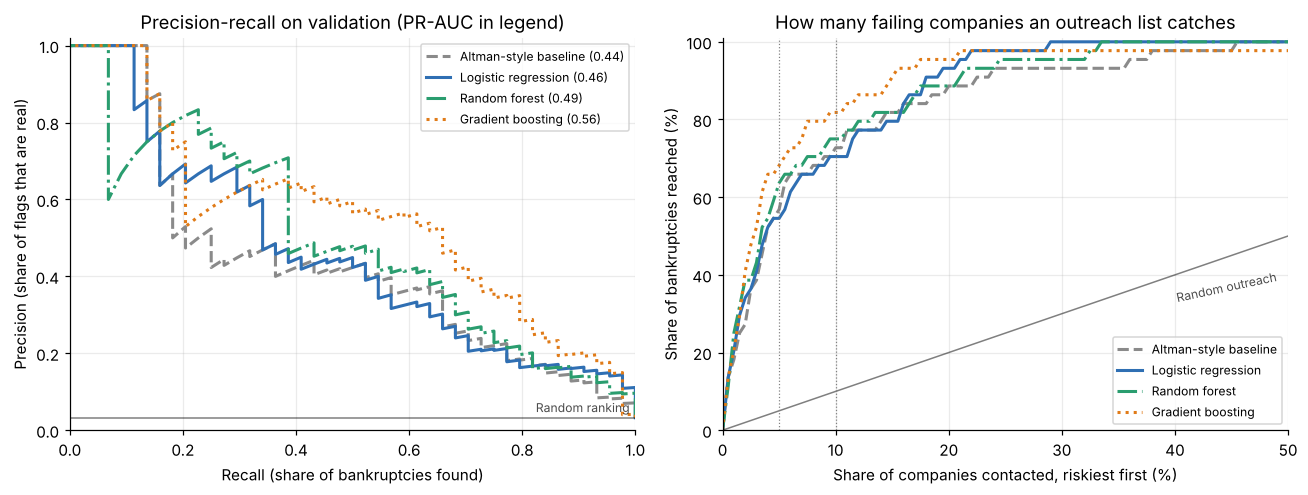

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# Left: precision-recall curves
ax = axes[0]
for name, s in val_scores.items():
    prec, rec, _ = precision_recall_curve(y_val, s)
    style = MODEL_STYLE[name]
    ax.plot(rec, prec, color=style['color'], ls=style['ls'], lw=2,
            label=f'{name} ({average_precision_score(y_val, s):.2f})')
ax.axhline(y_val.mean(), color='black', lw=1, alpha=0.5)
ax.text(0.99, y_val.mean() + 0.015, 'Random ranking', ha='right',
        fontsize=8, alpha=0.7)
ax.set(xlabel='Recall (share of bankruptcies found)',
       ylabel='Precision (share of flags that are real)',
       title='Precision-recall on validation (PR-AUC in legend)',
       xlim=(0, 1), ylim=(0, 1.02))
ax.legend(fontsize=8, loc='upper right')

# Right: capture (cumulative gains) curves
ax = axes[1]
shares = np.linspace(0, 0.5, 101)
for name, s in val_scores.items():
    style = MODEL_STYLE[name]
    ax.plot(shares * 100, [capture_at(y_val, s, p) * 100 if p > 0 else 0
                           for p in shares],
            color=style['color'], ls=style['ls'], lw=2, label=name)
ax.plot(shares * 100, shares * 100, color='black', lw=1, alpha=0.5)
ax.text(40, 33, 'Random outreach', fontsize=8, alpha=0.7, rotation=12)
for cut in (5, 10):
    ax.axvline(cut, color='grey', lw=0.8, ls=':')
ax.set(xlabel='Share of companies contacted, riskiest first (%)',
       ylabel='Share of bankruptcies reached (%)',
       title='How many failing companies an outreach list catches',
       xlim=(0, 50), ylim=(0, 101))
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
fig.savefig('figures/validation_curves.png', dpi=200, bbox_inches='tight')
plt.show()

In the precision-recall curve, all four models remain well above the random baseline. Precision decreases as recall increases. At 80% recall, gradient boosting maintains precision of about 0.32, or roughly one bankruptcy for every three companies flagged, while the other models are below 0.21. This shows the trade-off between identifying more bankruptcies and contacting more solvent companies.

The capture curve translates the ranking into outreach capacity. Contacting the highest-risk 10% of companies captures about 82% of the bankruptcies with gradient boosting and about 73% with the baseline. A random selection of the same number of companies would be expected to capture about 10%. After roughly 20% of companies are contacted, the curves begin to flatten and the differences between models become smaller.

## 6. Final model selection

The selected model is the one with the highest validation PR-AUC unless a simpler model falls within about 0.02. In that case, the simpler model would be preferred because it is easier to explain and implement. The cell below applies this rule.

In [12]:
ranked = comparison.sort_values('Val PR-AUC', ascending=False)
top_name = ranked.index[0]

# Prefer the simpler model when it is effectively tied with the top one
simplicity = ['Altman-style baseline', 'Logistic regression',
              'Random forest', 'Gradient boosting']
tied = ranked[ranked['Val PR-AUC'] >= ranked['Val PR-AUC'].iloc[0] - 0.02]
final_name = min(tied.index, key=simplicity.index)
final_model = fitted[final_name]

print(f'Highest validation PR-AUC: {top_name}')
print(f'Chosen model: {final_name}')

Highest validation PR-AUC: Gradient boosting
Chosen model: Gradient boosting


### 6.1 Risk tiers and the decision threshold

A model score by itself does not tell an outreach team who to contact first, so the scores are converted into three risk tiers. The cut points are defined using the validation set and then kept fixed before the test set is scored.

The Critical tier is the highest-risk 5% of companies and is contacted first, with the most intensive support. The Elevated tier is the next 10% and gets lighter check-ins as capacity allows. The Stable tier is everyone else and gets routine monitoring only.

The 5% and 10% tier sizes represent assumptions about outreach capacity rather than values learned from the data. In practice, the nonprofit would set these cutoffs based on the number of companies its staff can realistically work with.

As a sensitivity analysis, we also evaluate where the Critical threshold would fall if the cost of missing a bankruptcy were several times higher than the cost of contacting a solvent company. Because the actual cost ratio is unknown, we test several values (5x, 10x, 20x, and 30x) rather than assuming a specific dollar amount.

In [13]:
final_val = val_scores[final_name]
cut_critical = np.quantile(final_val, 0.95)
cut_elevated = np.quantile(final_val, 0.85)


def assign_tier(scores):
    """Map scores to tiers using the frozen validation cut points."""
    return np.where(scores >= cut_critical, 'Critical',
                    np.where(scores >= cut_elevated, 'Elevated', 'Stable'))


def tier_table(y_true, scores):
    """Summarize companies, bankruptcies and hit rate by tier."""
    t = pd.DataFrame({'tier': assign_tier(scores), 'y': np.asarray(y_true)})
    out = t.groupby('tier')['y'].agg(Companies='size', Bankrupt='sum')
    out = out.reindex(['Critical', 'Elevated', 'Stable'])
    out['Bankrupt rate'] = out['Bankrupt'] / out['Companies']
    out['Share of all bankruptcies'] = out['Bankrupt'] / out['Bankrupt'].sum()
    return out


print(f'Critical cut: score >= {cut_critical:.3f}')
print(f'Elevated cut: score >= {cut_elevated:.3f}')
tier_table(y_val, final_val).style.format(
    {'Bankrupt rate': '{:.1%}', 'Share of all bankruptcies': '{:.0%}'})

Critical cut: score >= 0.048
Elevated cut: score >= 0.001


,Companies,Bankrupt,Bankrupt rate,Share of all bankruptcies
tier,,,,
Critical,69,30,43.5%,68%
Elevated,136,10,7.4%,23%
Stable,1159,4,0.3%,9%


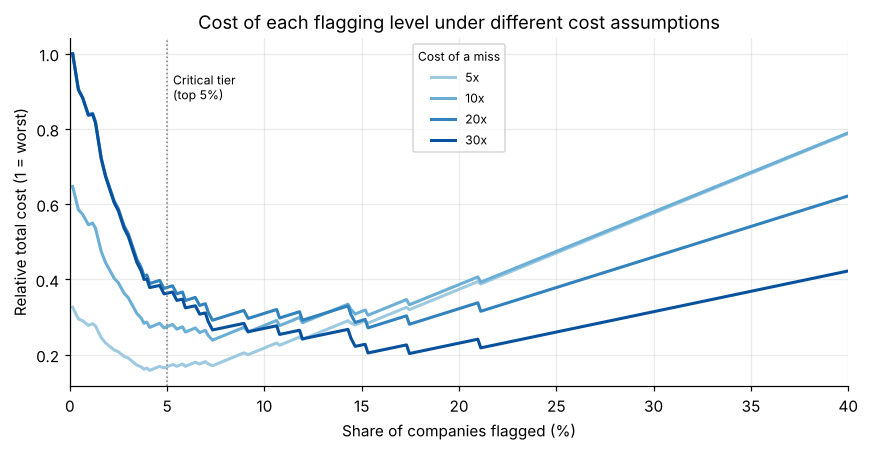

Miss costs this many times a false alarm,Best threshold,Share of companies flagged,Bankruptcies caught
5,0.115,4.1%,66%
10,0.013,7.3%,80%
20,0.001,15.3%,93%
30,0.000,17.4%,95%


In [14]:
# Cost sensitivity: which threshold minimizes cost for each assumed ratio?
thresholds = np.unique(np.quantile(final_val, np.linspace(0.5, 0.999, 300)))
ratios = [5, 10, 20, 30]
y_val_arr = y_val.to_numpy()

fig, ax = plt.subplots(figsize=(8, 4.2))
best_rows = []
for r, color in zip(ratios, ['#9ecae1', '#6baed6', '#3182bd', '#08519c']):
    costs = []
    for t in thresholds:
        flag = final_val >= t
        fp = np.sum(flag & (y_val_arr == 0))
        fn = np.sum(~flag & (y_val_arr == 1))
        costs.append(fp * 1 + fn * r)
    costs = np.array(costs)
    best_t = thresholds[costs.argmin()]
    best_rows.append({'Miss costs this many times a false alarm': r,
                      'Best threshold': best_t,
                      'Share of companies flagged':
                          (final_val >= best_t).mean(),
                      'Bankruptcies caught': capture_at(
                          y_val, final_val, (final_val >= best_t).mean())})
    ax.plot([(final_val >= t).mean() * 100 for t in thresholds],
            costs / costs.max(), color=color, lw=2, label=f'{r}x')

ax.axvline(5, color='grey', ls=':', lw=1)
ax.text(5.3, 0.95, 'Critical tier\n(top 5%)', fontsize=8, va='top')
ax.set(xlabel='Share of companies flagged (%)',
       ylabel='Relative total cost (1 = worst)',
       title='Cost of each flagging level under different cost assumptions',
       xlim=(0, 40))
ax.legend(title='Cost of a miss', fontsize=8, title_fontsize=8)
plt.tight_layout()
fig.savefig('figures/cost_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

pd.DataFrame(best_rows).style.format({
    'Best threshold': '{:.3f}', 'Share of companies flagged': '{:.1%}',
    'Bankruptcies caught': '{:.0%}'}).hide(axis='index')

The cost analysis shows how the preferred outreach threshold changes as missed bankruptcies become more expensive. If a missed bankruptcy is assumed to cost five times as much as contacting a solvent company, the lowest-cost strategy flags about 4% of companies, which is close to the Critical tier. At a 10x cost ratio, the preferred share increases to about 7%. At 20x or 30x, it increases to roughly 15% to 17%, which is close to contacting both the Critical and Elevated tiers.

This supports keeping both tiers available when the cost of missing a bankruptcy is relatively high. The Critical tier can be used for the highest-priority outreach, while the Elevated tier provides a broader second level of monitoring. The actual threshold should be adjusted if real outreach and failure costs become available.

The gradient boosting scores are useful for ranking companies, but they are not calibrated probabilities. For example, the Elevated cutoff occurs at a model score near 0.001 even though the observed bankruptcy rate in that tier is much higher. For that reason, reports should describe the output as a risk score, risk rank, or risk tier rather than a probability of bankruptcy unless the scores are calibrated first.

## 7. Results

### 7.1 Test set (scored once)

The selected model is now applied to the 1,364 test companies that were not used for model fitting, tuning, model selection, or threshold selection. The risk-tier cut points remain the values defined from the validation set.

In [15]:
test_scores = final_model.predict_proba(X_test)[:, 1]
base_test = fitted['Altman-style baseline'].predict_proba(X_test)[:, 1]

test_summary = pd.DataFrame({
    final_name: {
        'PR-AUC': average_precision_score(y_test, test_scores),
        'ROC-AUC': roc_auc_score(y_test, test_scores),
        'Capture @ 5%': capture_at(y_test, test_scores, 0.05),
        'Capture @ 15%': capture_at(y_test, test_scores, 0.15),
        'Hit rate @ 5%': precision_at(y_test, test_scores, 0.05)},
    'Altman-style baseline': {
        'PR-AUC': average_precision_score(y_test, base_test),
        'ROC-AUC': roc_auc_score(y_test, base_test),
        'Capture @ 5%': capture_at(y_test, base_test, 0.05),
        'Capture @ 15%': capture_at(y_test, base_test, 0.15),
        'Hit rate @ 5%': precision_at(y_test, base_test, 0.05)},
    'Random outreach': {
        'PR-AUC': y_test.mean(), 'ROC-AUC': 0.5,
        'Capture @ 5%': 0.05, 'Capture @ 15%': 0.15,
        'Hit rate @ 5%': y_test.mean()},
}).T
test_summary.to_csv('results/test_summary_macoi.csv')
test_summary.style.format('{:.3f}').format(
    '{:.0%}', subset=['Capture @ 5%', 'Capture @ 15%', 'Hit rate @ 5%'])

,PR-AUC,ROC-AUC,Capture @ 5%,Capture @ 15%,Hit rate @ 5%
Gradient boosting,0.469,0.951,61%,91%,39%
Altman-style baseline,0.368,0.950,59%,91%,38%
Random outreach,0.032,0.500,5%,15%,3%


In [16]:
test_tiers = tier_table(y_test, test_scores)
test_tiers.to_csv('results/test_tiers_macoi.csv')
test_tiers.style.format(
    {'Bankrupt rate': '{:.1%}', 'Share of all bankruptcies': '{:.0%}'})

,Companies,Bankrupt,Bankrupt rate,Share of all bankruptcies
tier,,,,
Critical,68,27,39.7%,61%
Elevated,123,12,9.8%,27%
Stable,1173,5,0.4%,11%


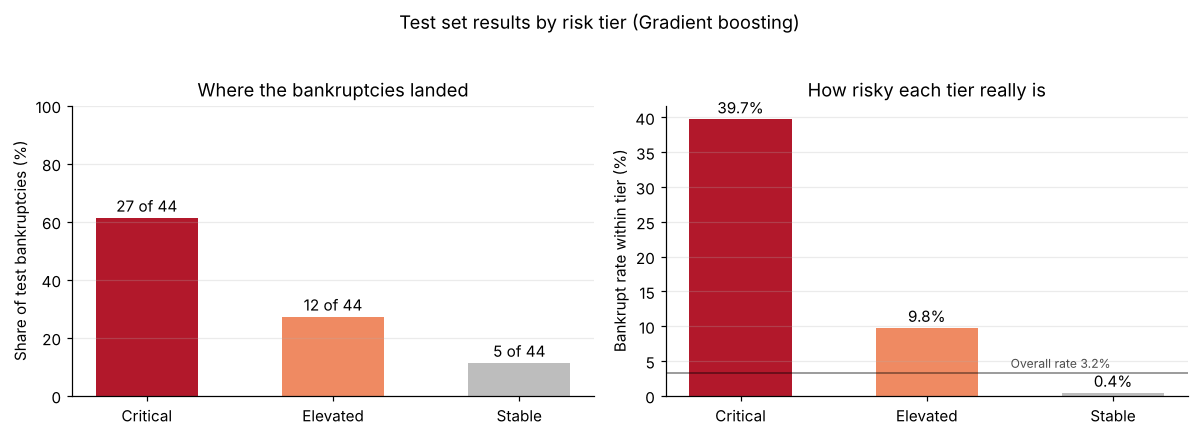

In [17]:
# Tier chart for the brief and slides
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
tiers = test_tiers.index.tolist()
tier_colors = ['#b2182b', '#ef8a62', '#bdbdbd']

ax = axes[0]
bars = ax.bar(tiers, test_tiers['Share of all bankruptcies'] * 100,
              color=tier_colors, width=0.55)
for b, n in zip(bars, test_tiers['Bankrupt']):
    ax.annotate(f'{n} of {int(test_tiers["Bankrupt"].sum())}',
                (b.get_x() + b.get_width() / 2, b.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center')
ax.set(ylabel='Share of test bankruptcies (%)',
       title='Where the bankruptcies landed', ylim=(0, 100))

ax = axes[1]
bars = ax.bar(tiers, test_tiers['Bankrupt rate'] * 100,
              color=tier_colors, width=0.55)
for b, rate in zip(bars, test_tiers['Bankrupt rate']):
    ax.annotate(f'{rate:.1%}', (b.get_x() + b.get_width() / 2,
                                b.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center')
ax.axhline(y_test.mean() * 100, color='black', lw=1, alpha=0.5)
ax.text(1.45, y_test.mean() * 100 + 0.8, f'Overall rate {y_test.mean():.1%}',
        fontsize=8, alpha=0.7)
ax.set(ylabel='Bankrupt rate within tier (%)',
       title='How risky each tier really is')

for ax in axes:
    ax.grid(axis='x', visible=False)
plt.suptitle(f'Test set results by risk tier ({final_name})', y=1.03)
plt.tight_layout()
fig.savefig('figures/test_tiers.png', dpi=200, bbox_inches='tight')
plt.show()

In [18]:
# Confusion matrix if outreach goes to the Critical tier only
flag = test_scores >= cut_critical
cm = confusion_matrix(y_test, flag)
cm_df = pd.DataFrame(cm, index=['Actually solvent', 'Actually bankrupt'],
                     columns=['Not flagged', 'Flagged (Critical)'])
cm_df

,Not flagged,Flagged (Critical)
Actually solvent,1279,41
Actually bankrupt,17,27


Performance decreases somewhat from validation to test, but the model continues to rank bankrupt companies well. On the 1,364-company test set, gradient boosting produces a PR-AUC of 0.47 compared with 0.37 for the baseline. The Critical tier contains 68 companies, 27 of which went bankrupt. That represents 61% of all test bankruptcies and a bankruptcy rate of about 40% within the tier. A random selection of 68 companies would be expected to identify only about two bankruptcies.

Using the fixed validation-based tier thresholds, the Critical and Elevated tiers together contain 39 of the 44 bankruptcies while covering about 14% of the test companies. The Stable tier contains the remaining five bankruptcies and has a bankruptcy rate of about 0.4%. When the ranking is evaluated as an exact top-15% list instead of the fixed tier thresholds, gradient boosting captures 91% of bankruptcies, or 40 of 44. The one-company difference occurs because the fixed score cutoffs do not produce exactly 15% of the test set.

If only the Critical tier is contacted, the confusion matrix shows 27 bankruptcies identified, 41 solvent companies contacted, and 17 bankruptcies missed. Most of those missed bankruptcies fall into the Elevated tier, which supports keeping a second outreach level rather than relying on the Critical tier alone.

At the very top of the test ranking, the baseline performs almost as well as gradient boosting. The baseline captures 26 of 44 bankruptcies in its top 5%, compared with 27 for gradient boosting, and both models capture 91% within an exact top-15% list. This means the larger model's advantage is clearer in overall ranking quality than in the very short outreach lists. Section 7.2 examines whether that pattern remains similar across additional random splits.

### 7.2 How stable are these numbers?

Each holdout set contains only about 44 bankruptcies, so results can change depending on which companies happen to appear in a particular split. To evaluate that variability, we keep each model's tuned settings, repeat the 60 / 20 / 20 split using five additional random seeds, refit the models on each new training set, and score each new validation set.

In [19]:
stability_rows = []
for seed in [1, 7, 21, 99, 123]:
    Xtr, Xtmp, ytr, ytmp = train_test_split(
        X, y, test_size=0.40, stratify=y, random_state=seed)
    Xv, _, yv, _ = train_test_split(
        Xtmp, ytmp, test_size=0.50, stratify=ytmp, random_state=seed)
    for name, model in fitted.items():
        m = clone(model)  # same tuned settings, fresh fit
        m.fit(Xtr, ytr)
        s = m.predict_proba(Xv)[:, 1]
        stability_rows.append({'Seed': seed, 'Model': name,
                               'PR-AUC': average_precision_score(yv, s),
                               'Capture @ 5%': capture_at(yv, s, 0.05)})

stability = pd.DataFrame(stability_rows)
stability_summary = stability.groupby('Model')[['PR-AUC', 'Capture @ 5%']].agg(
    ['mean', 'min', 'max']).reindex(list(MODEL_STYLE))
stability_summary.to_csv('results/seed_stability_macoi.csv')
stability_summary.style.format('{:.3f}')

Across the five additional splits, gradient boosting has the highest average PR-AUC (0.50 versus 0.38 for the baseline) and the highest average capture at 5% (60% versus 55%). However, the ranges overlap substantially. Gradient boosting PR-AUC ranges from 0.41 to 0.62, while the baseline ranges from 0.27 to 0.55. The baseline's top 5% captures between 48% and 70% of bankruptcies depending on the split.

Gradient boosting produces a higher PR-AUC than the baseline in all five additional splits, which suggests that its ranking improvement is reasonably consistent. The practical difference at the top 5% is smaller: depending on the split, gradient boosting identifies between zero and three additional bankruptcies compared with the baseline, and it identified five additional bankruptcies on the original validation split. With only about 44 bankruptcies in each holdout set, those small count differences should be interpreted cautiously. Logistic regression and random forest also do not show a consistent advantage over one another.

One limitation of this check is that the tuned hyperparameters were selected using the original training split, while the new validation sets overlap with data involved in that tuning process. This may slightly favor the tuned models relative to the untuned baseline, so the true performance gap could be somewhat smaller than the table suggests.

### 7.3 What drives the risk score

Permutation importance is calculated on the validation set by shuffling one feature at a time and measuring how much PR-AUC decreases. This approach works with any model and is measured using the original feature names, so any raw-scale indicator associated with a feature is included with that feature.

In [20]:
perm = permutation_importance(
    final_model, X_val, y_val, scoring='average_precision',
    n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1)

importance = pd.DataFrame({
    'Feature': X_val.columns,
    'PR-AUC drop': perm.importances_mean,
    'sd': perm.importances_std,
}).sort_values('PR-AUC drop', ascending=False)

# Direction: medians for bankrupt vs solvent training companies, using
# only normal-scale values (raw-scale cells are left out, as in 2.1)
X_train_clean = X_train.mask(X_train > 1)
importance['Median if bankrupt'] = [
    X_train_clean.loc[y_train == 1, f].median()
    for f in importance['Feature']]
importance['Median if solvent'] = [
    X_train_clean.loc[y_train == 0, f].median()
    for f in importance['Feature']]
importance.head(15).style.format(
    {'PR-AUC drop': '{:.4f}', 'sd': '{:.4f}',
     'Median if bankrupt': '{:.4f}', 'Median if solvent': '{:.4f}'}
).hide(axis='index')

Feature,PR-AUC drop,sd,Median if bankrupt,Median if solvent
Quick Ratio,0.0682,0.0304,0.0028,0.0076
Accounts Receivable Turnover,0.0448,0.0085,0.0010,0.0010
Research and development expense rate,0.0423,0.0118,0.0000,0.0001
Persistent EPS in the Last Four Seasons,0.0422,0.0077,0.1958,0.2250
Net Value Growth Rate,0.0382,0.0072,0.0004,0.0005
Non-industry income and expenditure/revenue,0.0380,0.0089,0.3033,0.3035
Interest-bearing debt interest rate,0.0355,0.0216,0.0005,0.0003
Net worth/Assets,0.0327,0.0133,0.8130,0.8909
Continuous interest rate (after tax),0.0292,0.0158,0.7813,0.7816
Net Value Per Share (B),0.0237,0.0038,0.1580,0.1846


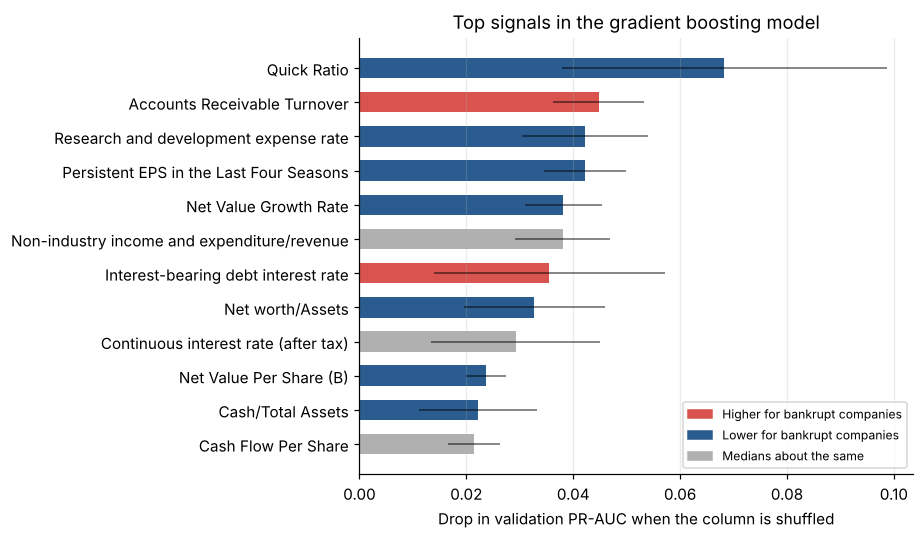

In [21]:
top = importance.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, 5))
gap = ((top['Median if bankrupt'] - top['Median if solvent'])
       / top['Median if solvent'].abs())
colors = np.select([gap > 0.02, gap < -0.02],
                   [PALETTE['Bankrupt'], PALETTE['Solvent']], '#b0b0b0')
ax.barh(top['Feature'], top['PR-AUC drop'], xerr=top['sd'],
        color=colors, height=0.6, error_kw={'lw': 1, 'alpha': 0.6})
ax.set(xlabel='Drop in validation PR-AUC when the column is shuffled',
       title=f'Top signals in the {final_name.lower()} model')
ax.grid(axis='y', visible=False)
ax.legend(handles=[
    Patch(color=PALETTE['Bankrupt'], label='Higher for bankrupt companies'),
    Patch(color=PALETTE['Solvent'], label='Lower for bankrupt companies'),
    Patch(color='#b0b0b0', label='Medians about the same')],
    fontsize=8, loc='lower right')
plt.tight_layout()
fig.savefig('figures/top_signals.png', dpi=200, bbox_inches='tight')
plt.show()

No single feature dominates the model. Shuffling `Quick Ratio`, the most important feature in this analysis, reduces validation PR-AUC by about 0.07. The remaining top features reduce PR-AUC by approximately 0.02 to 0.05. The error bars are fairly wide, so the exact ordering beyond the first few features should not be interpreted too strongly.

The most important signals mostly make financial sense. Bankrupt companies have lower liquidity, with median `Quick Ratio` and `Cash/Total Assets` values at about one-third of the solvent median. They also have lower and less stable earnings through measures such as `Persistent EPS` and `Net Value Per Share`, a smaller equity cushion (`Net worth/Assets` of about 0.81 compared with 0.89), and a higher cost of debt.

Some highly ranked variables, including `Non-industry income and expenditure/revenue` and `Continuous interest rate (after tax)`, have similar medians for bankrupt and solvent companies. Their predictive value appears to come from unusual values in the tails of the distributions rather than a large difference in the center. Tree-based models can capture those nonlinear patterns more easily than linear logistic regression, which may help explain part of gradient boosting's advantage.

The permutation importance ranking also differs from the strongest correlations identified during the EDA, especially the ROA and net-income-to-assets variables. This does not mean profitability is unimportant. The dataset contains several closely related profitability measures, including three ROA variables. When one correlated feature is shuffled, similar information may still be available through another feature, so permutation importance can spread importance across the group rather than assigning it to a single variable.

### 7.4 Where the model fails

The test bankruptcies left in the Stable tier are especially important to review because they show the types of companies the model is most likely to miss. If those companies appear financially healthy based on the available ratios, a ratio-based model may have limited ability to identify them in advance.

In [22]:
test_view = X_test.copy()
test_view['tier'] = assign_tier(test_scores)
test_view['bankrupt'] = y_test.values

caught = test_view[(test_view['bankrupt'] == 1)
                   & (test_view['tier'] != 'Stable')]
missed = test_view[(test_view['bankrupt'] == 1)
                   & (test_view['tier'] == 'Stable')]
solvent = test_view[test_view['bankrupt'] == 0]

key_cols = importance['Feature'].head(6).tolist()
def clean_median(frame):
    """Median of normal-scale values only."""
    return frame[key_cols].mask(frame[key_cols] > 1).median()


profile = pd.DataFrame({
    'Caught (Critical or Elevated)': clean_median(caught),
    'Missed (left in Stable)': clean_median(missed),
    'Solvent companies': clean_median(solvent),
})
print(f'Caught: {len(caught)}, missed: {len(missed)}')
profile.style.format('{:.4f}')

Caught: 39, missed: 5


,Caught (Critical or Elevated),Missed (left in Stable),Solvent companies
Quick Ratio,0.0022,0.0046,0.0078
Accounts Receivable Turnover,0.0009,0.0010,0.0010
Research and development expense rate,0.0000,nan,0.0001
Persistent EPS in the Last Four Seasons,0.1940,0.2078,0.2258
Net Value Growth Rate,0.0004,0.0004,0.0005
Non-industry income and expenditure/revenue,0.3033,0.3035,0.3035


Only five of the 44 test bankruptcies fall into the Stable tier, so this comparison should be treated as a pattern to investigate rather than a firm conclusion. On several important features, the missed companies fall between the bankruptcies the model identified and the solvent companies. Their median quick ratio is 0.0046, compared with 0.0022 for the bankruptcies that were captured and 0.0078 for solvent companies. Their median earnings per share is 0.208, which is close to the solvent median of 0.226. Based on these measures, the missed companies appear financially healthier than the bankruptcies the model successfully identified, although their liquidity is still weaker. Their R&D median is unavailable because all five had raw-scale R&D values.

This highlights an important limitation of the model. It is most effective when financial deterioration is already visible in the ratios. A company that fails because of information not represented in these variables, such as fraud, loss of a major customer, litigation, or a sudden credit disruption, may still receive a lower-risk ranking. The model should therefore be treated as one input to outreach decisions rather than the only decision rule. Limiting outreach to the Critical tier would increase the number of missed bankruptcies from five to 17, which shows why the Elevated tier is useful.

False positives are the other major limitation. Of the 68 companies in the Critical tier, 41 did not go bankrupt. Some may have been financially distressed and later recovered, but the dataset does not contain enough information to distinguish those cases from model errors. These false positives use outreach capacity, but the sensitivity analysis in Section 6.1 shows why accepting some false positives may still be reasonable when the cost of missing a bankruptcy is higher.

## 8. Model brief

To: Project team and analysts continuing this work  
Re: First-pass bankruptcy risk model, results, limitations, and next steps

The goal was to build a bankruptcy risk ranking that helps a nonprofit outreach team decide which companies to contact first when its staff can only work with a limited number of companies. We evaluated the models using PR-AUC and capture within the highest-risk 5% and 15% of companies rather than relying on accuracy. Because only 3.2% of companies in the dataset went bankrupt, a model could achieve high accuracy while still failing to identify the companies that matter most.

Before modeling, we identified a scaling issue in 24 columns. Most values in these columns fall between 0 and 1, while a smaller number are recorded in the millions or billions with no values between the two scales. We treated values above 1 as unusable on the normalized scale, replaced them with the training median, and added an indicator for columns with at least 10 raw-scale observations in training. The indicator preserves information that may still be useful. For example, companies with a raw `Cash/Current Liability` value have a bankruptcy rate about ten times higher than the remaining companies. This preprocessing decision should be reviewed because the EDA originally treated these values as genuine outliers.

We compared four models using a fixed 60 / 20 / 20 split. The baseline is a logistic regression based on five ratios related to Altman's Z-score. We compared it with a tuned L2 logistic regression using the pruned feature set, a random forest, and a histogram gradient boosting model. The tuned models use class weighting rather than resampling. An elastic-net logistic regression was also tested, but the `saga` solver had not converged after 5,000 iterations, so it was not used in the final comparison.

Gradient boosting performs best on validation with a PR-AUC of 0.56 and remains strongest on the held-out test set with a PR-AUC of 0.47, compared with 0.37 for the baseline. In an exact top-5% test ranking, gradient boosting captures 27 of 44 bankruptcies. In an exact top-15% ranking, it captures 40 of 44. Using the fixed risk-tier thresholds defined from validation, the Critical and Elevated tiers together contain 39 of 44 bankruptcies because those fixed score cutoffs cover about 14% rather than exactly 15% of the test set.

Overall, the five-ratio baseline captures much of the available predictive signal, while gradient boosting provides a smaller additional improvement. Gradient boosting has a higher PR-AUC than the baseline across the original comparison and all five additional random splits, but the difference in the top 5% outreach list is modest. Depending on the split, the larger model identifies between zero and five additional bankruptcies out of roughly 44, with most of the additional splits showing a difference of only a few companies. The baseline therefore remains a reasonable fallback when simplicity and interpretability are more important than the smaller improvement in ranking performance.

Several limitations affect how these results should be interpreted. The dataset does not include dates, so we cannot determine how long before bankruptcy the financial ratios were recorded. The model can separate higher-risk from lower-risk companies, but it cannot show how much advance warning the ranking provides. The companies are Taiwanese, and the data covers 1999 to 2009, so the results may not transfer directly to different countries, accounting environments, industries, or current credit conditions. With only about 44 bankruptcies in each holdout set, every metric is sensitive to a small number of companies. The gradient boosting scores are also not calibrated probabilities, so they should be reported as risk scores, rankings, or tiers rather than as a direct probability of bankruptcy. Finally, the tier sizes and cost ratios used in the sensitivity analysis are assumptions about outreach capacity and relative cost, not values provided by the dataset.

Recommended next steps include widening the hyperparameter search ranges because several selected values fall near the edge of the ranges tested, including gradient boosting's 360 iterations and 46 leaves and the logistic regression `C` value of 0.004. The scores could then be calibrated using isotonic regression or Platt scaling if interpretable probabilities are needed. SMOTE could also be compared with the current class-weighting approach. A smaller model using approximately the top 15 to 20 signals may provide similar performance with easier interpretation, and SHAP values could help explain why an individual company receives a high-risk ranking. Outside the scope of this course, the most useful next step would be obtaining dated financial filings so the model could be tested on whether it identifies risk one or two years before bankruptcy.

## References

Altman, E. I. (1968). Financial ratios, discriminant analysis and the prediction of corporate bankruptcy. *The Journal of Finance, 23*(4), 589–609. https://doi.org/10.1111/j.1540-6261.1968.tb00843.x

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Yeh, C. (2020). *Taiwanese bankruptcy prediction* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5004D